# Chapter 10: A Deep Dive into Stable Diffusion

Open in Colab:
    
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/18lCSmwzqQ3r1pqPXocX2H8p-QmpkzJAv?usp=sharing)

This chapter covers:

* Differences between Stable Diffusion and the latent diffusion model
* Integrating Stable Diffusion in the diffusers library 
* Various components of Stable Diffusion and their roles in text-to-image generation
* Interpolating text embeddings to generate a series of images that smoothly transition from one image to another


Stable Diffusion is based on the latent diffusion model (LDM) that we discussed in the previous chapter. It's one of the state-of-the-art text-to-image models, along with OpenAI's DALL-E series and Google's Imagen. However, Stable Diffusion is the only one that is open-source and free for anyone to use.

Stable Diffusion is developed collaboratively by researchers from CompVis, Stability AI, and LAION. It's grounded in the innovative techniques described in the influential 2022 paper by Rombach et al.  Stable Diffusion has incorporated a host of improvements that enhance both the model’s stability and performance. For instance, advanced training techniques and optimizations have been employed to produce higher-quality images with greater consistency. Moreover, while the original LDM was trained on the LAION-400M dataset (with 400 million image-text pairs), Stable Diffusion uses a subset of the even larger LAION-5B database, offering a richer and more diverse training foundation.
Beyond its technical advancements, Stable Diffusion has been designed with accessibility in mind. Its user-friendly applications and interfaces democratize the power of high-quality generative models, allowing users without deep technical expertise to explore and create state-of-the-art visual content from simple text prompts.

In this chapter, you will learn how to harness the capabilities of Stable Diffusion using the Hugging Face diffusers library. We begin by demonstrating how to generate striking images with out-of-the-box tools, providing a hands-on introduction to the process. From there, we will peel back the layers of the model to reveal its main components. You will explore how the variational autoencoder (VAE), the denoising U-Net, and the CLIP text encoder work together to transform a text prompt into coherent, high-resolution images.

One of the most compelling aspects of this exploration is the technique of text embedding interpolation. By blending the embeddings of two different text prompts, you will observe how various mixtures of the conditioning information lead to a smooth visual transition between two images. For example, interpolating between the embeddings for “a lion” and “a tiger” will produce a series of images that gradually morph from a lion to a tiger. This step-by-step progression illustrates the power of conditional generation in diffusion models in general and underscores how text prompts steer the final output in particular.

By the end of this chapter, you will be equipped not only to generate impressive images from textual descriptions using Stable Diffusion but also to understand the various processes that drive these results. This deeper insight into the architecture and function of Stable Diffusion will empower you to experiment further and potentially innovate in text-to-image generation.

# 1. Generate Images with Stable Diffusion
In this section, you'll learn how to create high-resolution images by using a version of the Stable Diffusion that's integrated into the Hugging Face diffusers library. To install the library, run the following line of code in Jupyter Notebook.

In [1]:
!pip install diffusers


The StableDiffusionPipeline package in the diffusers library allows you to use Stable Diffusion as an off-the-shelf tool to generate great images in just a few lines of code.

Let's use the prompt "an astronaut in a spacesuit riding a unicorn" to generate an image:

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

C:\Users\ssd2t\anaconda3\envs\txt2img\Lib\site-packages\transformers\models\clip\modeling_clip.py:491: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


  0%|          | 0/50 [00:00<?, ?it/s]

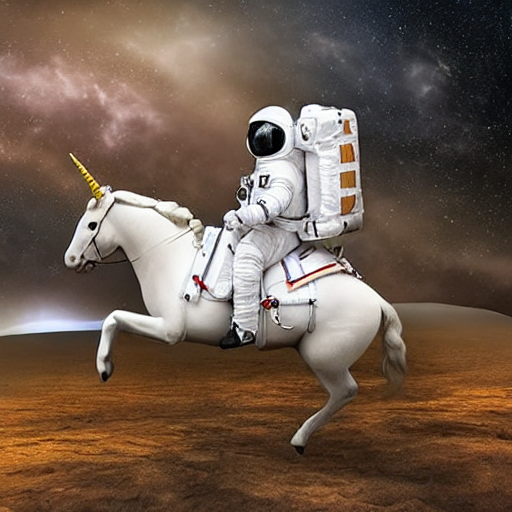

In [2]:
import torch
from diffusers import StableDiffusionPipeline

torch.manual_seed(42)
prompt="an astronaut in a spacesuit riding a unicorn"
pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4", 
    variant="fp16",
    torch_dtype=torch.float16).to("cuda")
image = pipe(prompt).images[0]
image.save(f"files/{prompt}.png")
image

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

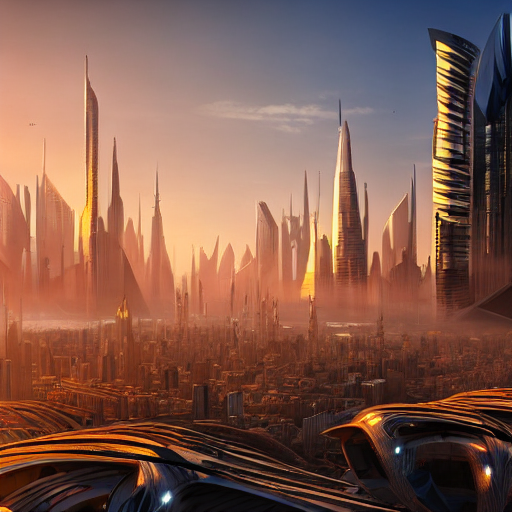

In [3]:
# exercise 10.1
torch.manual_seed(42)
prompt='a futuristic city at sunrise'
pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4", 
    variant="fp16",
    torch_dtype=torch.float16).to("cuda")
image = pipe(prompt).images[0]
image

  0%|          | 0/50 [00:00<?, ?it/s]

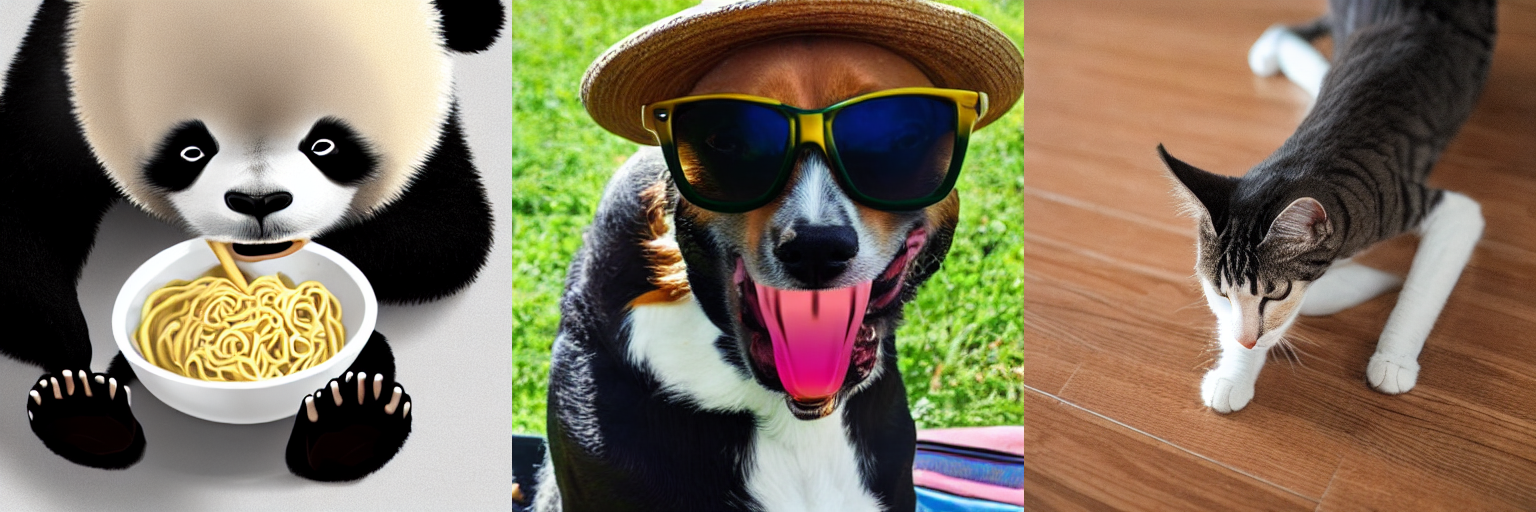

In [4]:
from PIL import Image

torch.manual_seed(0)
prompts = ["a panda eating a bowl of noodles",
    "a dog with sunglasses and a straw hat",
    "a cat stretching on the floor"] 
images = pipe(prompts).images
grid = Image.new('RGB', size=(3*images[0].size[0],
                  images[0].size[1]))
for i, img in enumerate(images):
    grid.paste(img, box=(i*images[0].size[0], 0))
grid.save("files/three_prompts.png")
grid

  0%|          | 0/50 [00:00<?, ?it/s]

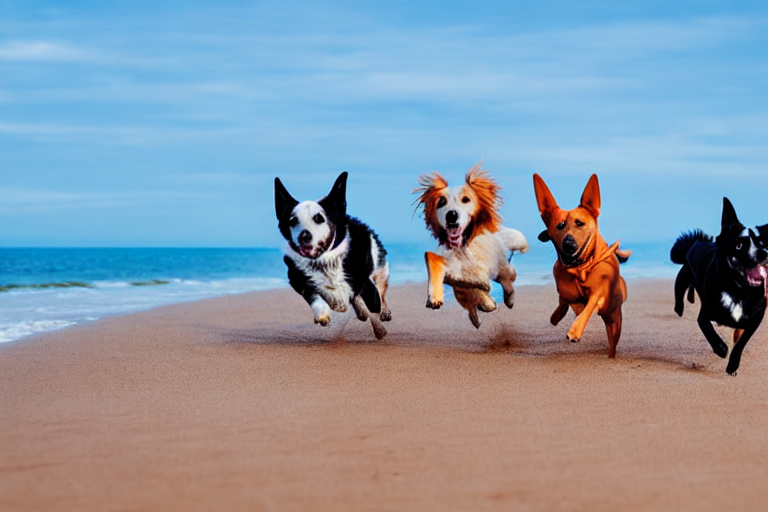

In [5]:
torch.manual_seed(42)
prompt = "dogs running on a sandy beach under blue sky" 
images = pipe(prompt,width=768,height=512,
             guidance_scale=12).images
images[0].save(f"files/{prompt}.png")
images[0]

# 2. The Stable Diffusion architecture
# 3. Create text embeddings

In [6]:
class Config:
    height = 512    # height of the generated image                       
    width = 512    # width of the generated image                               
    guidance_scale = 7.5    # CFG-guidance paraemter                
    num_inference_steps=50    # number of inference steps
config=Config()

prompts1 = ["a lion"]
prompts2 = ["a tiger"] 

In [7]:
from transformers import CLIPTextModel, CLIPTokenizer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = CLIPTokenizer.from_pretrained(
    "openai/clip-vit-large-patch14")
text_encoder = CLIPTextModel.from_pretrained(
    "openai/clip-vit-large-patch14").to(device)

Now we can tokenize the text prompts into a sequence of indexes:

In [8]:
tokens1=tokenizer(prompts1,padding="max_length", 
              max_length=tokenizer.model_max_length, 
              truncation=True, return_tensors="pt")
tokens2=tokenizer(prompts2,padding="max_length", 
              max_length=tokenizer.model_max_length, 
              truncation=True, return_tensors="pt")
with torch.no_grad():
    text_embeddings1=text_encoder(
        tokens1.input_ids.to(device))[0]
    text_embeddings2=text_encoder(
        tokens2.input_ids.to(device))[0]  
print("text embedding 1 shape:", text_embeddings1.shape)
print("text embedding 2 shape:", text_embeddings1.shape)

text embedding 1 shape: torch.Size([1, 77, 768])
text embedding 2 shape: torch.Size([1, 77, 768])


In [9]:
# exercise 10.2
prompts3 = ["a leopard"]
prompts4 = ["a lioness"] 
tokens3=tokenizer(prompts3,padding="max_length", 
              max_length=tokenizer.model_max_length, 
              truncation=True, return_tensors="pt")
tokens4=tokenizer(prompts4,padding="max_length", 
              max_length=tokenizer.model_max_length, 
              truncation=True, return_tensors="pt")
with torch.no_grad():
    text_embeddings3=text_encoder(tokens3.input_ids.to(device))[0]
    text_embeddings4=text_encoder(tokens4.input_ids.to(device))[0]   

In [10]:
unconditional_prompt = [""]
uncond_input = tokenizer(unconditional_prompt, 
             padding="max_length", 
             max_length=tokenizer.model_max_length, 
             return_tensors="pt")
with torch.no_grad():
    uncond_embeds=text_encoder(
        uncond_input.input_ids.to(device))[0] 

# 4 Image Generation in the Latent Space


In [11]:
from diffusers import LMSDiscreteScheduler
from diffusers import UNet2DConditionModel

scheduler = LMSDiscreteScheduler(beta_start=0.00085,
                     beta_end=0.012, 
                     beta_schedule="scaled_linear", 
                     num_train_timesteps=1000)

unet = UNet2DConditionModel.from_pretrained(
    "CompVis/stable-diffusion-v1-4", subfolder="unet")
unet = unet.to(device)

In [12]:
from tqdm import tqdm

def gen_latents(text_embeddings, seed):
    torch.manual_seed(seed)
    scheduler.set_timesteps(config.num_inference_steps)
    latents = torch.randn((1, unet.config.in_channels, 
           config.height // 8, config.width // 8)).to(device)
    latents = latents * scheduler.init_noise_sigma 
    text_embeddings=torch.cat([uncond_embeds, text_embeddings])
    with torch.autocast(device):  
        for i, t in tqdm(enumerate(scheduler.timesteps)):
            latent_model_input = torch.cat([latents] * 2)
            sigma = scheduler.sigmas[i]
            latent_model_input = scheduler.scale_model_input(
                latent_model_input, t)
            with torch.no_grad():
                noise_pred = unet(latent_model_input, t, 
                  encoder_hidden_states=text_embeddings).sample
            noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
            noise_pred=noise_pred_uncond+config.guidance_scale*(
                noise_pred_text - noise_pred_uncond)
            latents = scheduler.step(noise_pred,
                                     t, latents).prev_sample
    return 1 / 0.18215 * latents

In [13]:
latents1=gen_latents(text_embeddings1,seed=5)
latents2=gen_latents(text_embeddings2,seed=5)
print(f"latent image size is {latents1[0].shape}")

50it [00:06,  7.22it/s]
50it [00:06,  7.54it/s]

latent image size is torch.Size([4, 64, 64])


In [14]:
# exercise 10.3
# make sure you set the seed number to 8
latents3=gen_latents(text_embeddings3,seed=8)
latents4=gen_latents(text_embeddings4,seed=8)
print(f"latent image size is {latents3[0].shape}")

50it [00:06,  7.55it/s]
50it [00:06,  7.80it/s]

latent image size is torch.Size([4, 64, 64])


# 4. Convert latent images to high-resolution ones


In [15]:
from diffusers import AutoencoderKL

vae = AutoencoderKL.from_pretrained(
      "CompVis/stable-diffusion-v1-4", 
      subfolder="vae").to(device)

Now, we can convert the latent images to high resolution images. 

In [16]:
with torch.no_grad():
    images1 = vae.decode(latents1).sample
    images2 = vae.decode(latents2).sample    
print(f"final image size is {images2[0].shape}")    

final image size is torch.Size([3, 512, 512])


In [17]:
# exercise 10.4
with torch.no_grad():
    images3 = vae.decode(latents3).sample
    images4 = vae.decode(latents4).sample    
print(f"final image size is {images4[0].shape}") 

final image size is torch.Size([3, 512, 512])


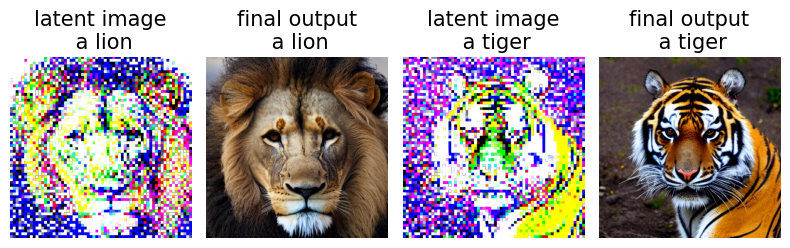

In [18]:
import matplotlib.pyplot as plt
import numpy as np 

imgs=[torch.clip(latents1[0].permute(1,2,0),-1,1).detach().cpu(
    ).numpy().repeat(8, axis=0).repeat(8,axis=1)/2+0.5,
  torch.clip(images1[0].detach().cpu().permute(1,2,0)/2+0.5,0,1),
    torch.clip(latents2[0].permute(1,2,0),-1,1).detach().cpu(
    ).numpy().repeat(8, axis=0).repeat(8,axis=1)/2+0.5,
  torch.clip(images2[0].detach(
      ).cpu().permute(1,2,0)/2+0.5,0,1)]   

captions=["latent image\n a lion",
          "final output\n a lion",
          "latent image\n a tiger",
          "final output\n a tiger"]

plt.figure(figsize=(8,5),dpi=100)
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(imgs[i])
    plt.title(captions[i],fontsize=15)    
    plt.axis('off')
plt.tight_layout()
plt.show()

Now we can visualize the high-resolution final images.

The images have high resolutions and match the text descriptions. You can experiment with various hyperparameters such as the guidance scale parameter, number of inference steps and so on. 

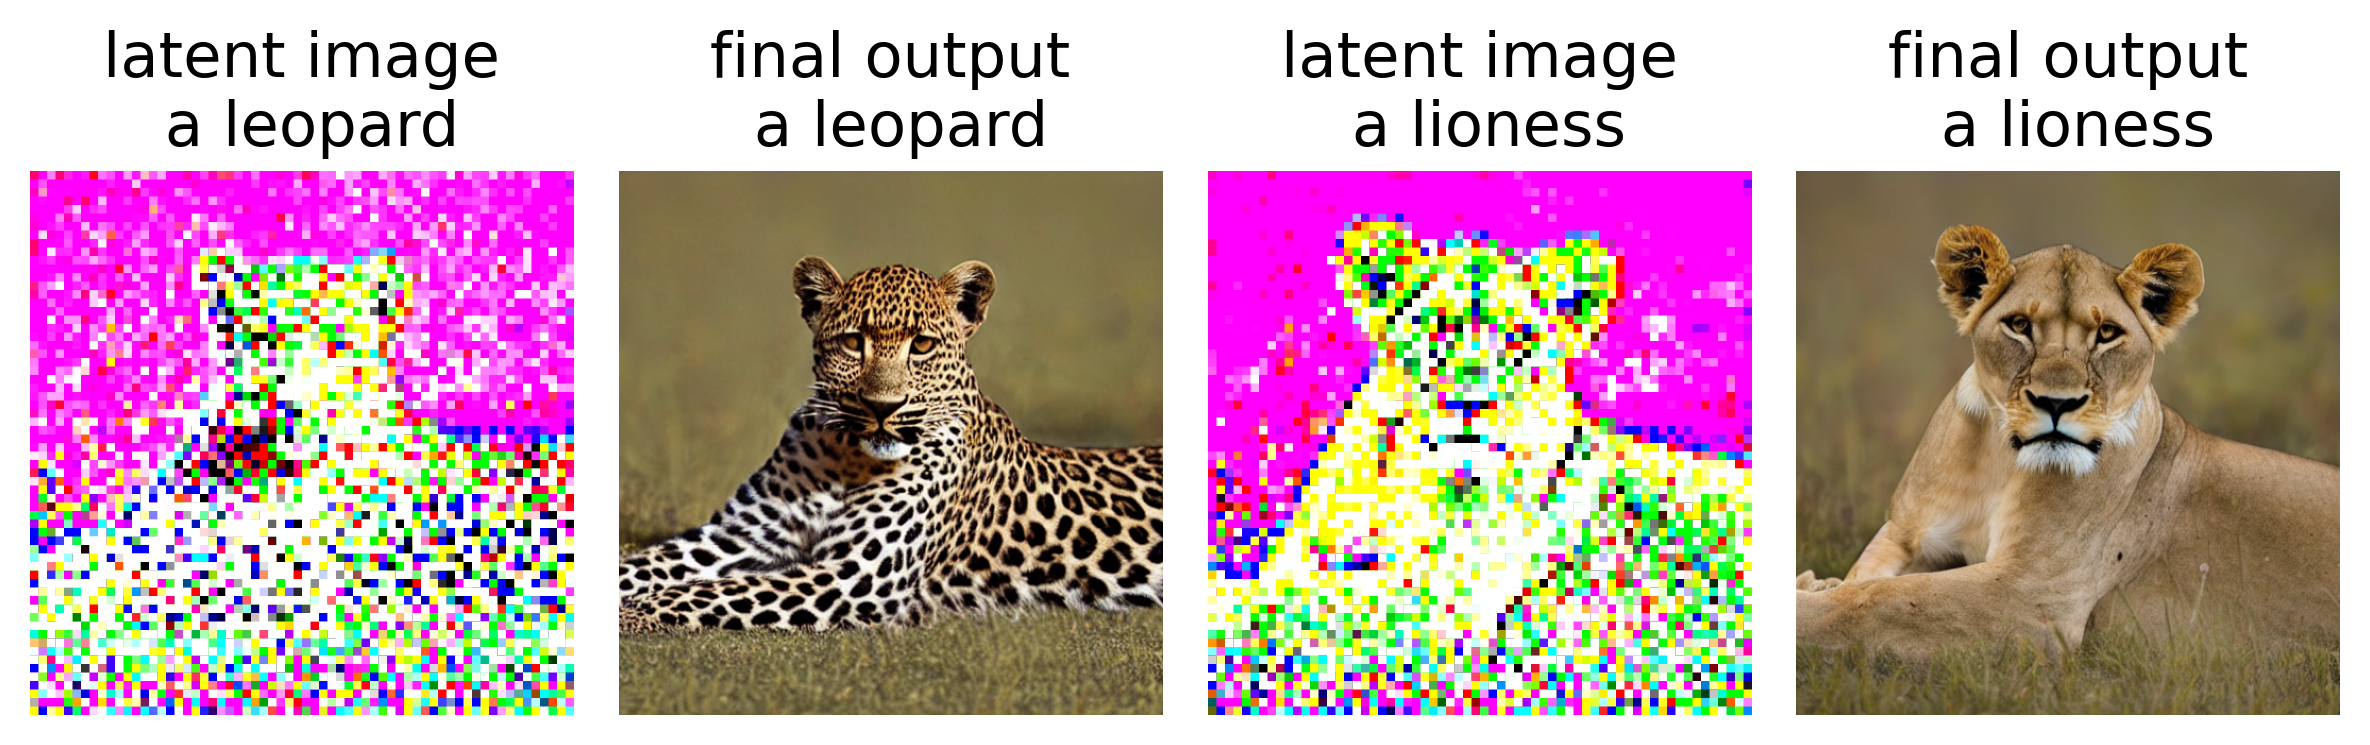

In [19]:
# exercise 10.5
imgs=[torch.clip(latents3[0].permute(1,2,0),-1,1).detach().cpu(
    ).numpy().repeat(8, axis=0).repeat(8,axis=1)/2+0.5,
  torch.clip(images3[0].detach().cpu().permute(1,2,0)/2+0.5,0,1),
    torch.clip(latents4[0].permute(1,2,0),-1,1).detach().cpu(
    ).numpy().repeat(8, axis=0).repeat(8,axis=1)/2+0.5,
  torch.clip(images4[0].detach().cpu().permute(1,2,0)/2+0.5,0,1)]   

captions=["latent image\n a leopard",
          "final output\n a leopard",
          "latent image\n a lioness",
          "final output\n a lioness",]

plt.figure(figsize=(8,5),dpi=300)
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(imgs[i])
    plt.title(captions[i],fontsize=15)    
    plt.axis('off')
plt.tight_layout()
plt.show()

The images have high resolution and match the text descriptions. You can experiment with various hyperparameters such as the guidance scale parameter, number of inference steps and so on. 

In [20]:
# interpolate
images=[]
for weight in [0.9, 0.7, 0.5, 0.3, 0.1]:
    text_embeddings = weight * text_embeddings1 +\
        (1-weight) * text_embeddings2
    latents=gen_latents(text_embeddings,seed=5)
    with torch.no_grad():
        images.append(vae.decode(latents).sample)

50it [00:06,  7.43it/s]
50it [00:06,  7.45it/s]
50it [00:06,  7.73it/s]
50it [00:06,  7.52it/s]
50it [00:06,  7.56it/s]


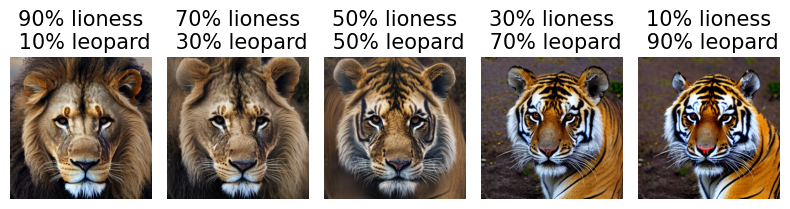

In [21]:
plt.figure(figsize=(8,5),dpi=100)
for i in range(5):
    plt.subplot(1,5,i+1)
    img=torch.clip(images[i][0].detach().cpu(
        ).permute(1,2,0)/2+0.5,0,1)
    plt.imshow(img)
    plt.title(f"{90-20*i}% lioness\n {10+20*i}% leopard",
              fontsize=15)    
    plt.axis('off')
plt.tight_layout()
plt.show()

50it [00:06,  7.50it/s]
50it [00:06,  7.69it/s]
50it [00:06,  7.65it/s]
50it [00:06,  7.59it/s]
50it [00:06,  7.56it/s]


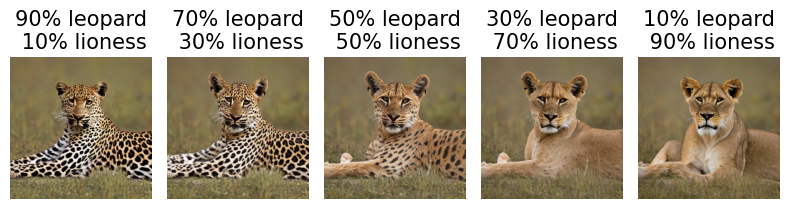

In [22]:
# exercise 10.6
#interpolate
images=[]
for weight in [0.9, 0.7, 0.5, 0.3, 0.1]:
    text_embeddings = weight * text_embeddings3 +\
        (1-weight) * text_embeddings4
    latents=gen_latents(text_embeddings,seed=8)
    with torch.no_grad():
        images.append(vae.decode(latents).sample)
 
plt.figure(figsize=(8,5),dpi=100)
for i in range(5):
    plt.subplot(1,5,i+1)
    img=torch.clip(images[i][0].detach().cpu(
        ).permute(1,2,0)/2+0.5,0,1)
    plt.imshow(img)
    plt.title(f"{90-20*i}% leopard\n {10+20*i}% lioness",
              fontsize=15)    
    plt.axis('off')
plt.tight_layout()
plt.show()